# 합성곱 신경망의 시각화

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 전체 요약:
### 합성곱 신경망(CNN)의 가중치와 특성 맵을 시각화하는 과정을 단계별로 설명합니다. 케라스 모델의 가중치 분포, 학습 전후의 필터 시각화, 함수형 API 사용, 특성 맵 추출 및 시각화 방법을 다룹니다.

**합성곱 신경망(CNN)**의 작동 방식을 시각적으로 이해하는 방법에 대한 설명입니다.

---

### **핵심 내용 요약**

* **합성곱 신경망(CNN) 시각화**: 훈련된 CNN 모델이 어떤 특징을 학습하는지 알아보기 위해 **가중치(필터)**와 **특성 맵**을 시각화합니다.
* **가중치(필터) 시각화**: 필터는 이미지의 특정 패턴(예: 선, 점)을 감지하는 역할을 합니다. 훈련 전에는 가중치가 무작위로 초기화되지만, 훈련 후에는 특정 패턴을 감지하도록 변형된 모습을 시각적으로 확인할 수 있습니다.
* **특성 맵 시각화**: 각 합성곱 층의 출력을 '특성 맵'이라고 하는데, 이것을 그림으로 볼 수 있습니다.
    * **초기 층**: 입력 이미지(예: 앵클부츠)와 비슷한 저수준의 패턴을 감지합니다.
    * **깊은 층**: 층이 깊어질수록 점점 더 추상적이고 복잡한 패턴을 감지하며, 원래 이미지와는 다른 형태가 나타납니다.

---

### **프로그램 개발 관련 내용 (함수형 API)**

* **함수형 API**: 케라스에서 모델을 만드는 또 다른 방법으로, 모델의 중간층 출력을 쉽게 얻기 위해 사용됩니다.
* **사용법**: 각 층을 별도의 변수에 저장하고, 이 변수를 함수처럼 호출하여 층들을 연결합니다. 마지막으로 `keras.Model` 클래스에 입력과 출력을 지정해 모델을 완성합니다.
* **장점**: 중간층의 출력을 확인하거나, 입력과 출력이 여러 개인 복잡한 모델을 만들 때 유용합니다.

간단히 말해, 이 강의는 CNN이 이미지를 어떻게 '이해'하고 '학습'하는지 필터와 특성 맵이라는 것을 직접 눈으로 확인하는 방법에 대해 설명합니다.

In [1]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

[추가]
### 셀 3: 케라스 및 텐서플로 랜덤 시드 설정
- **역할:** 실험의 재현성을 위해 케라스와 텐서플로의 랜덤 시드를 고정합니다.
- **주요 메소드:**
  - `keras.utils.set_random_seed(seed)`: 케라스의 난수 시드 설정
  - `tf.random.set_seed(seed)`: 텐서플로의 난수 시드 설정
  - `tf.config.experimental.enable_op_determinism()`: 연산의 결정론적 실행 보장

## 가중치 시각화

In [2]:
# 코랩에서 실행하는 경우에는 다음 명령을 실행하여 best-cnn-model.keras 파일을 다운로드받아 사용하세요.
!wget https://github.com/rickiepark/hg-mldl/raw/master/best-cnn-model.keras

'wget' is not recognized as an internal or external command,
operable program or batch file.


[추가]
### 셀 6: 사전 학습된 모델 다운로드
- **역할:** 코랩 환경에서 미리 학습된 CNN 모델 파일을 다운로드합니다.
- **주요 명령:**
  - `!wget`: 외부 파일 다운로드

In [3]:
import keras
model = keras.models.load_model('best-cnn-model.keras')

[추가]
### 셀 7: 모델 로드
- **역할:** 저장된 케라스 모델을 메모리로 불러옵니다.
- **주요 메소드:**
  - `keras.models.load_model(filepath)`: 저장된 모델 로드

In [4]:
model.layers

[<Conv2D name=conv2d_4, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Flatten name=flatten_2, built=True>,
 <Dense name=dense_4, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_5, built=True>]

[추가]
### 셀 8: 모델 레이어 확인
- **역할:** 모델의 레이어 구조를 확인합니다.
- **주요 속성:**
  - `model.layers`: 모델의 레이어 리스트

In [5]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


[추가]
### 셀 9: 합성곱 레이어의 가중치 형태 확인
- **역할:** 첫 번째 합성곱 레이어의 가중치와 편향의 shape을 출력합니다.
- **주요 속성:**
  - `conv.weights[0]`: 합성곱 필터 가중치
  - `conv.weights[1]`: 합성곱 레이어의 편향

In [6]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


[추가]
### 셀 10: 합성곱 가중치의 통계량 확인
- **역할:** 합성곱 레이어의 가중치 평균과 표준편차를 출력합니다.
- **주요 메소드:**
  - `numpy()`: 텐서 값을 넘파이 배열로 변환
  - `mean()`, `std()`: 배열의 평균, 표준편차 계산

In [7]:
conv_weights = conv.weights[0].numpy()

print(conv_weights.mean(), conv_weights.std())

0.014366064 0.11371624


[추가]
### 셀 11: 합성곱 가중치 분포 시각화
- **역할:** 합성곱 레이어의 가중치 분포를 히스토그램으로 시각화합니다.
- **주요 라이브러리:**
  - `matplotlib.pyplot.hist`: 히스토그램 그리기

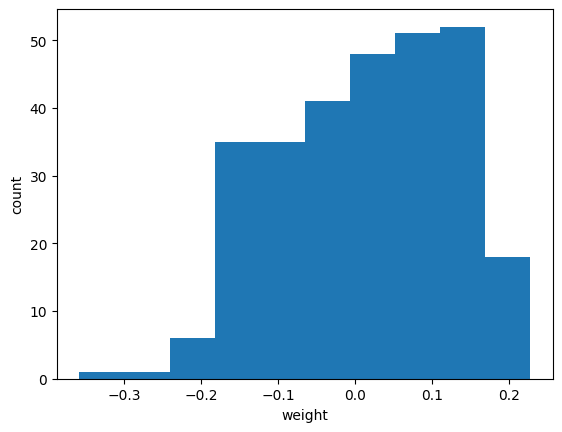

In [8]:
import matplotlib.pyplot as plt

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

[추가]
### 셀 12: 합성곱 필터 시각화
- **역할:** 학습된 합성곱 필터(가중치)를 이미지로 시각화합니다.
- **주요 메소드:**
  - `imshow`: 2D 배열을 이미지로 표시
  - `axis('off')`: 축 숨기기

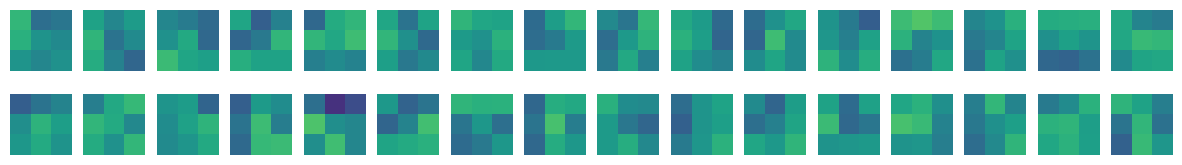

In [9]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

[추가]
### 셀 13: 학습되지 않은 합성곱 레이어 모델 생성
- **역할:** 임의로 초기화된 합성곱 레이어를 갖는 모델을 생성합니다.
- **주요 클래스:**
  - `keras.Sequential`, `keras.layers.Input`, `keras.layers.Conv2D`

In [10]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                                          padding='same'))

[추가]
### 셀 14: 학습되지 않은 합성곱 레이어의 가중치 형태 확인
- **역할:** 임의 초기화된 합성곱 레이어의 가중치 shape을 출력합니다.

In [11]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


[추가]
### 셀 15: 학습되지 않은 합성곱 가중치의 통계량 확인
- **역할:** 임의 초기화된 합성곱 레이어의 가중치 평균과 표준편차를 출력합니다.

In [12]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

0.0053191613 0.08463709


[추가]
### 셀 16: 학습되지 않은 합성곱 가중치 분포 시각화
- **역할:** 임의 초기화된 합성곱 레이어의 가중치 분포를 히스토그램으로 시각화합니다.

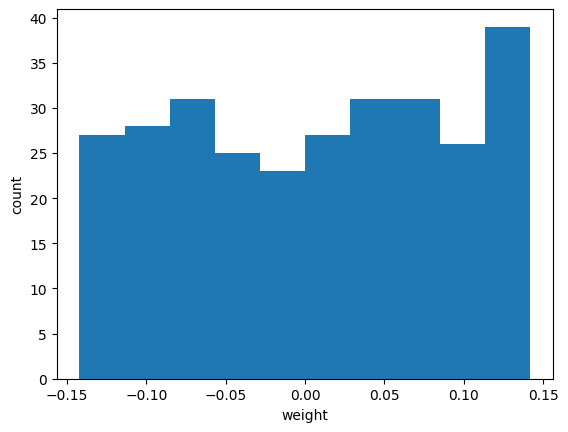

In [13]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

[추가]
### 셀 17: 학습되지 않은 합성곱 필터 시각화
- **역할:** 임의 초기화된 합성곱 필터(가중치)를 이미지로 시각화합니다.

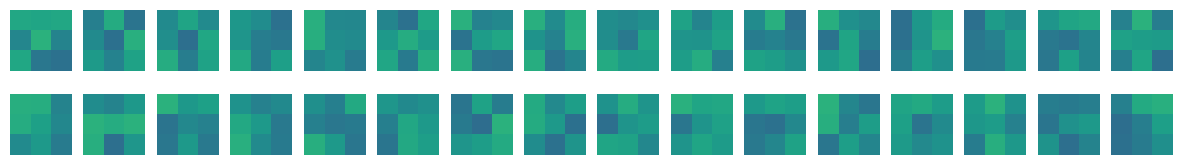

In [14]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

## 함수형 API

In [15]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs)
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)

[추가]
### 셀 21: 함수형 API 모델 생성
- **역할:** 케라스 함수형 API를 사용하여 입력, 은닉, 출력 레이어를 연결한 모델을 생성합니다.
- **주요 클래스 및 메소드:**
  - `keras.Input`, `keras.layers.Dense`, `keras.Model`

In [16]:
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]


[추가]
### 셀 22: 모델 입력 텐서 확인
- **역할:** 모델의 입력 텐서를 출력하여 입력 형태를 확인합니다.

In [17]:
conv_acti = keras.Model(model.inputs, model.layers[0].output)

## 특성 맵 시각화

In [18]:
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

[추가]
### 셀 26: Fashion MNIST 데이터셋 로드
- **역할:** Fashion MNIST 데이터셋을 로드하여 학습/테스트 데이터를 준비합니다.
- **주요 메소드:**
  - `keras.datasets.fashion_mnist.load_data()`

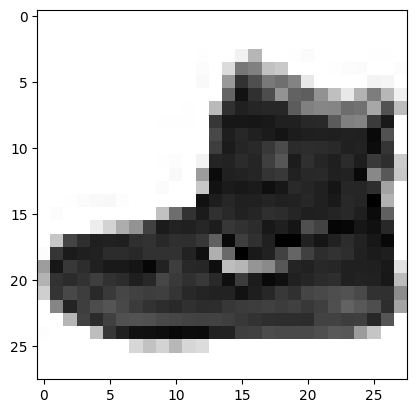

In [19]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

[추가]
### 셀 27: 입력 이미지 시각화
- **역할:** Fashion MNIST의 첫 번째 이미지를 시각화합니다.

In [20]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1)/255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


[추가]
### 셀 28: 입력 데이터 전처리 및 특성 맵 추출
- **역할:** 이미지를 전처리하여 첫 번째 합성곱 레이어의 특성 맵을 추출합니다.
- **주요 메소드:**
  - `reshape`, `/255.0`: 정규화 및 차원 변환
  - `predict`: 모델 예측(특성 맵 추출)

In [21]:
print(feature_maps.shape)

(1, 28, 28, 32)


[추가]
### 셀 29: 특성 맵 shape 확인
- **역할:** 추출된 특성 맵의 shape을 출력합니다.

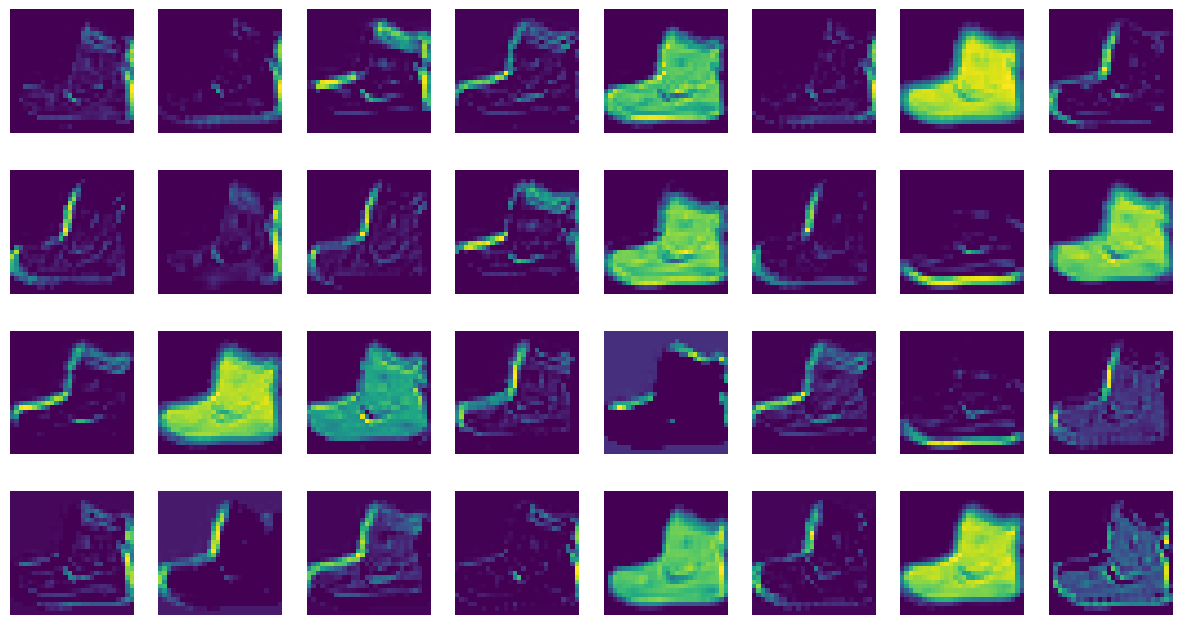

In [22]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()

[추가]
### 셀 31: 두 번째 합성곱 레이어의 특성 맵 추출 모델 생성
- **역할:** 두 번째 합성곱 레이어의 출력을 반환하는 모델을 생성합니다.

In [23]:
conv2_acti = keras.Model(model.inputs, model.layers[2].output)

[추가]
### 셀 32: 두 번째 합성곱 특성 맵 추출
- **역할:** 두 번째 합성곱 레이어의 특성 맵을 추출합니다.

In [24]:
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


[추가]
### 셀 33: 두 번째 합성곱 특성 맵 shape 확인
- **역할:** 두 번째 합성곱 레이어의 특성 맵 shape을 출력합니다.

In [25]:
print(feature_maps.shape)

(1, 14, 14, 64)


[추가]
### 셀 34: 두 번째 합성곱 특성 맵 시각화
- **역할:** 두 번째 합성곱 레이어의 특성 맵을 2D 이미지로 시각화합니다.

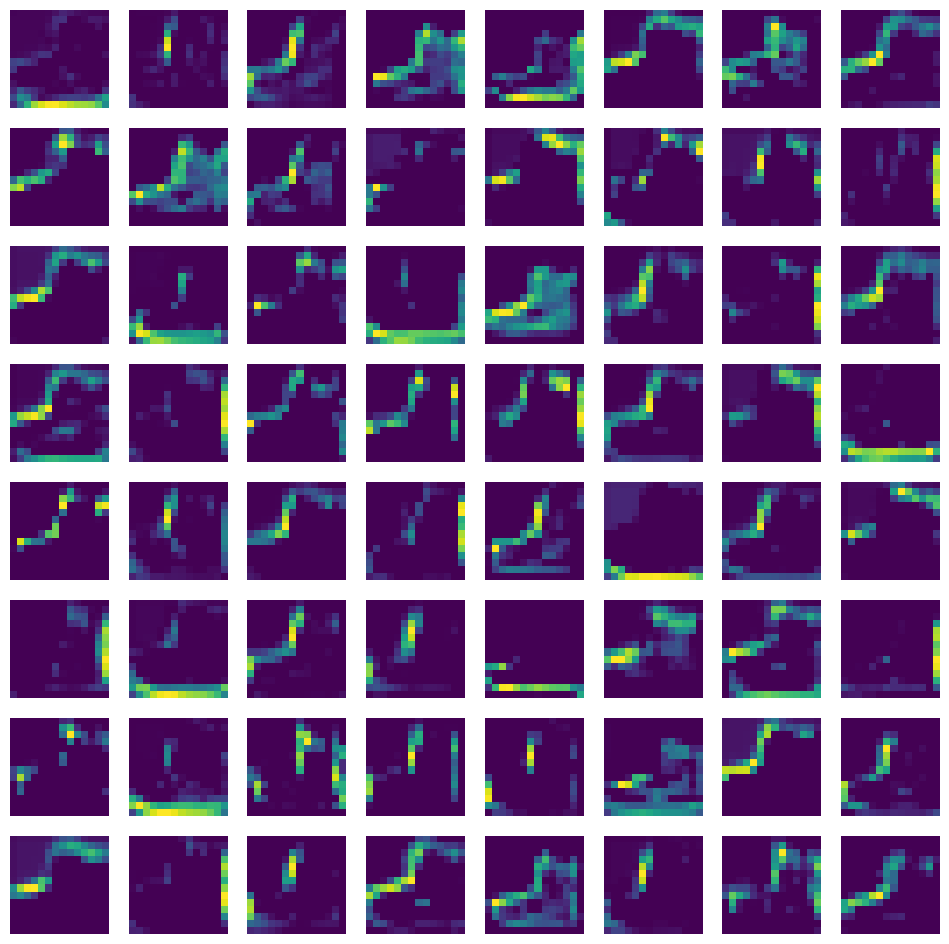

In [26]:
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()